# Training Model (Efficientb0)
## Setup and Imports

In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. DEFINE PATHS (RAW STRINGS)
CSV_PATH       = r"../data/processed/Labels_0.6.csv"
IMAGE_DIR      = r"../data/processed/preprocessed_glaucoma"
MODEL_DIR      = r"../models"
TRAIN_SPLIT_PATH = Path(r"../Data/Processed/train_split.csv")   # relative: up one folder from notebooks/
VAL_SPLIT_PATH   = Path(r"../Data/Processed/val_split.csv")
TEST_SPLIT_PATH  = Path(r"../Data/Processed/test_split.csv")

# ---- Create the directory if it doesn't exist ----
TRAIN_SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
VAL_SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
TEST_SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)

print("Saving train split to:", TRAIN_SPLIT_PATH.resolve())
print("Saving val split to:", VAL_SPLIT_PATH.resolve())
print("Saving test split to:", TEST_SPLIT_PATH.resolve())


Saving train split to: C:\Users\Lee Pei En\Documents\Competition _ Challenges\idcs 2026\team108_idcs2026\data\processed\train_split.csv
Saving val split to: C:\Users\Lee Pei En\Documents\Competition _ Challenges\idcs 2026\team108_idcs2026\data\processed\val_split.csv
Saving test split to: C:\Users\Lee Pei En\Documents\Competition _ Challenges\idcs 2026\team108_idcs2026\data\processed\test_split.csv


## Data Inspection and Patient‑Level Splitting
Split train / val / test

In [ ]:
import random
import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import train_test_split

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Load CSV
df = pd.read_csv(CSV_PATH)

df = df[['Image Name', 'Label_Binary']].dropna().copy()

# Extract Patient ID
df["Patient_ID"] = df["Image Name"].apply(lambda x: x.split("_")[0])

print("Total patients:", df["Patient_ID"].nunique())

# Create patient-level dataframe
patient_df = df.groupby("Patient_ID")["Label_Binary"].first().reset_index()

# Train / Temp split (70%)
train_patients, temp_patients = train_test_split(
    patient_df,
    test_size=0.3,
    stratify=patient_df["Label_Binary"],
    random_state=42
)

# Validation / Test split (15% / 15%)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5,  
    stratify=temp_patients["Label_Binary"],
    random_state=42
)

# Map patient split back to images
train_df = df[df["Patient_ID"].isin(train_patients["Patient_ID"])]
val_df = df[df["Patient_ID"].isin(val_patients["Patient_ID"])]
test_df = df[df["Patient_ID"].isin(test_patients["Patient_ID"])]

# Print dataset sizes
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

# Label distribution
print("\nTrain label distribution:")
print(train_df["Label_Binary"].value_counts())

print("\nValidation label distribution:")
print(val_df["Label_Binary"].value_counts())

print("\nTest label distribution:")
print(test_df["Label_Binary"].value_counts())

# Save splits
train_df.to_csv(TRAIN_SPLIT_PATH, index=False)
val_df.to_csv(VAL_SPLIT_PATH, index=False)
test_df.to_csv(TEST_SPLIT_PATH, index=False)

print("\nSplits saved successfully.")

label_check = df.groupby("Patient_ID")["Label_Binary"].nunique()
mixed_label_patients = label_check[label_check > 1]

print("Patients with mixed labels:", len(mixed_label_patients))
print(mixed_label_patients.head())

# CHECK DATA LEAKAGE BETWEEN TRAIN / VAL / TEST
train_ids = set(train_df["Patient_ID"])
val_ids = set(val_df["Patient_ID"])
test_ids = set(test_df["Patient_ID"])

print("Train-Val overlap:", train_ids & val_ids)
print("Train-Test overlap:", train_ids & test_ids)
print("Val-Test overlap:", val_ids & test_ids)

print("\nDataset sizes:")
print("Train patients:", len(train_ids))
print("Val patients:", len(val_ids))
print("Test patients:", len(test_ids))

Total patients: 207
Train size: 300
Validation size: 61
Test size: 73

Train label distribution:
Label_Binary
1    215
0     85
Name: count, dtype: int64

Validation label distribution:
Label_Binary
1    44
0    17
Name: count, dtype: int64

Test label distribution:
Label_Binary
1    47
0    26
Name: count, dtype: int64

Splits saved successfully.
Patients with mixed labels: 0
Series([], Name: Label_Binary, dtype: int64)
Train-Val overlap: set()
Train-Test overlap: set()
Val-Test overlap: set()

Dataset sizes:
Train patients: 144
Val patients: 31
Test patients: 32


## Dataset Class and Transforms
### Create dataset class

In [5]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

class GlaucomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_name = self.dataframe.loc[idx, 'Image Name']
        label = self.dataframe.loc[idx, 'Label_Binary']

        image_path = os.path.join(self.image_dir, image_name)
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

### Define transforms

These images were already preprocessed to retinal crops and resized during the preprocessing notebook.
So the training augmentation should preserve anatomy and avoid a second random crop.

In [6]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.05, hue=0.01),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## DataLoaders and Hyperparameters

In [7]:
from torch.utils.data import DataLoader

# Hyperparameters
BATCH_SIZE = 16
STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 15
STAGE1_LR = 5e-4
STAGE2_LR = 3e-5
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 5

image_dir = str(IMAGE_DIR)

train_dataset = GlaucomaDataset(train_df, image_dir, transform=train_transform)
val_dataset = GlaucomaDataset(val_df, image_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()
print("Using unweighted BCEWithLogitsLoss")


Train batches: 19
Val batches: 4
Using unweighted BCEWithLogitsLoss


## Model Definition (Two‑Stage Fine‑Tuning)

1. freeze backbone and train only the classifier head
2. unfreeze layer3 + layer4 + fc with a smaller learning rate


In [8]:
import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Stage 1: freeze full backbone
for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 1)
)

model = model.to(DEVICE)
print("Using device:", DEVICE)

Using device: cpu


## Loss and Optimizer

Monitor validation AUC instead of only validation loss.


In [9]:
import torch.optim as optim

def make_optimizer(model, lr):
    return optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

def make_scheduler(optimizer):
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=2
    )

optimizer = make_optimizer(model, STAGE1_LR)
scheduler = make_scheduler(optimizer)


## Training / evaluation functions

Track accuracy, F1, recall, precision, and ROC-AUC.


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def compute_binary_metrics(all_labels, all_probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in all_probs]
    metrics = {
        "acc": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
    }
    return metrics


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs).detach().cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().flatten())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_labels, all_probs, threshold=0.5)
    return epoch_loss, metrics


def evaluate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().flatten())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_labels, all_probs, threshold=threshold)
    return epoch_loss, metrics


def find_best_threshold(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy().flatten())

    best_thresh = 0.5
    best_f1 = -1.0

    for t in np.arange(0.30, 0.71, 0.02):
        preds = [1 if p >= t else 0 for p in all_probs]
        f1 = f1_score(all_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = float(t)

    return best_thresh, best_f1


## Training model

Train in two stages and keep the checkpoint with the best validation AUC.


In [11]:
import copy

best_val_auc = -1.0
best_model_wts = copy.deepcopy(model.state_dict())
best_stage = None
patience_counter = 0

history = {
    "epoch": [],
    "stage": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_auc": [],
    "val_auc": [],
    "val_recall": [],
    "lr": [],
}


def run_training_stage(stage_name, epochs, optimizer, scheduler):
    global best_val_auc, best_model_wts, best_stage, patience_counter

    print(f"\n===== {stage_name} =====\n")
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_metrics = evaluate_one_epoch(model, val_loader, criterion, DEVICE, threshold=0.5)

        scheduler.step(val_metrics["auc"])
        current_lr = optimizer.param_groups[0]['lr']

        history["epoch"].append(len(history["epoch"]) + 1)
        history["stage"].append(stage_name)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])
        history["train_auc"].append(train_metrics["auc"])
        history["val_auc"].append(val_metrics["auc"])
        history["val_recall"].append(val_metrics["recall"])
        history["lr"].append(current_lr)

        print(f"{stage_name} Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train AUC : {train_metrics['auc']:.4f} | Val AUC : {val_metrics['auc']:.4f}")
        print(f"Train F1  : {train_metrics['f1']:.4f} | Val F1  : {val_metrics['f1']:.4f}")
        print(f"Val Recall: {val_metrics['recall']:.4f} | LR: {current_lr:.8f}")

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            best_model_wts = copy.deepcopy(model.state_dict())
            best_stage = stage_name
            patience_counter = 0
            print("Validation AUC improved. Model checkpoint updated.\n")
        else:
            patience_counter += 1
            print(f"No AUC improvement. Early stop counter: {patience_counter}/{EARLY_STOP_PATIENCE}\n")
            if patience_counter >= EARLY_STOP_PATIENCE:
                print(f"Early stopping triggered for {stage_name}.\n")
                break


# Stage 1: train classifier only
run_training_stage("Stage 1 (classifier only)", STAGE1_EPOCHS, optimizer, scheduler)

# Stage 2: unfreeze last EfficientNet blocks + classifier
for name, param in model.named_parameters():
    if "features.6" in name or "features.7" in name or "features.8" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = make_optimizer(model, STAGE2_LR)
scheduler = make_scheduler(optimizer)
run_training_stage("Stage 2 (last blocks + classifier)", STAGE2_EPOCHS, optimizer, scheduler)

print(f"Best validation AUC: {best_val_auc:.4f} from {best_stage}")


===== Stage 1 (classifier only) =====

Stage 1 (classifier only) Epoch [1/5]
Train Loss: 0.6190 | Val Loss: 0.5138
Train AUC : 0.5772 | Val AUC : 0.8864
Train F1  : 0.7942 | Val F1  : 0.8381
Val Recall: 1.0000 | LR: 0.00050000
Validation AUC improved. Model checkpoint updated.

Stage 1 (classifier only) Epoch [2/5]
Train Loss: 0.5065 | Val Loss: 0.4590
Train AUC : 0.8256 | Val AUC : 0.9131
Train F1  : 0.8448 | Val F1  : 0.8544
Val Recall: 1.0000 | LR: 0.00050000
Validation AUC improved. Model checkpoint updated.

Stage 1 (classifier only) Epoch [3/5]
Train Loss: 0.4589 | Val Loss: 0.4221
Train AUC : 0.9008 | Val AUC : 0.9492
Train F1  : 0.8600 | Val F1  : 0.8713
Val Recall: 1.0000 | LR: 0.00050000
Validation AUC improved. Model checkpoint updated.

Stage 1 (classifier only) Epoch [4/5]
Train Loss: 0.3976 | Val Loss: 0.3932
Train AUC : 0.9572 | Val AUC : 0.9639
Train F1  : 0.8996 | Val F1  : 0.9072
Val Recall: 1.0000 | LR: 0.00050000
Validation AUC improved. Model checkpoint updated.



## Load Best Model and Tune Threshold on Validation Set


In [12]:
model.load_state_dict(best_model_wts)
print("Best model loaded.")

best_thresh, best_val_f1 = find_best_threshold(model, val_loader, DEVICE)
print(f"Best validation threshold: {best_thresh:.2f}")
print(f"Best validation F1 at tuned threshold: {best_val_f1:.4f}")

Best model loaded.
Best validation threshold: 0.40
Best validation F1 at tuned threshold: 0.9778


## Save Checkpoint and Artifacts

We save the model weights, the best threshold, and other metadata. This checkpoint will be used in a separate test notebook.


In [ ]:
import os

training_artifact_dir = r"../models"
os.makedirs(training_artifact_dir, exist_ok=True)

checkpoint_path = os.path.join(
    training_artifact_dir,
    "augmented_glaucoma_efficientnet_b0.pth"
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": "efficientnet_b0",
    "best_threshold": float(best_thresh),
    "best_val_f1_at_threshold": float(best_val_f1),
    "best_val_auc": float(best_val_auc),
    "best_stage": best_stage,
    "image_dir": image_dir,
    "train_split_csv": r"../data/processed/train_split.csv",
    "val_split_csv": r"../data/processed/val_split.csv",
    "test_split_csv": r"../data/processed/test_split.csv",
    "batch_size": BATCH_SIZE,
}

torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")

# FINAL SUMMARY
print("Training notebook complete.")
print(f"Best validation AUC      : {best_val_auc:.4f}")
print(f"Best validation threshold: {best_thresh:.2f}")
print(f"Best validation F1       : {best_val_f1:.4f}")
print("Use the separate test notebook to evaluate on test_split.csv.")

Checkpoint saved to: ../models\augmented_glaucoma_efficientnet_b0.pth
Training notebook complete.
Best validation AUC      : 0.9920
Best validation threshold: 0.40
Best validation F1       : 0.9778
Use the separate test notebook to evaluate on test_split.csv.


## Plot training curves

These plots summarize the training-only workflow.


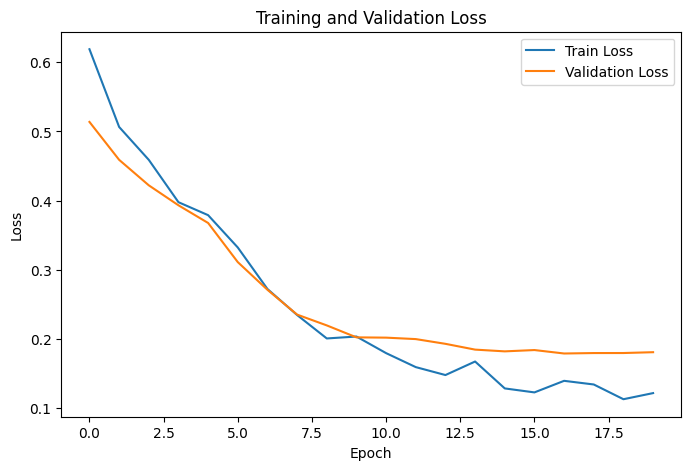

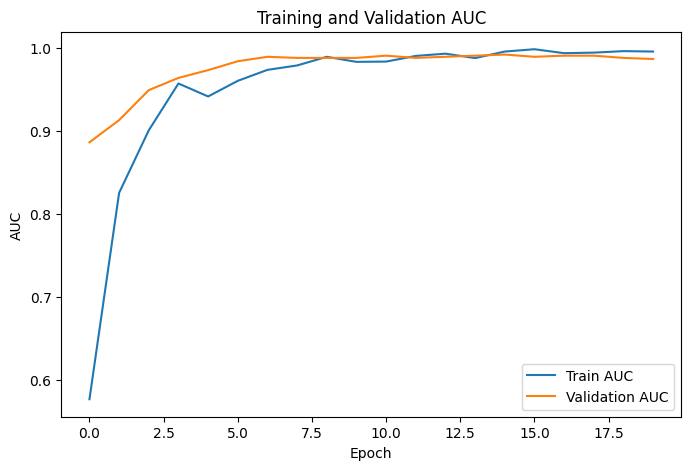

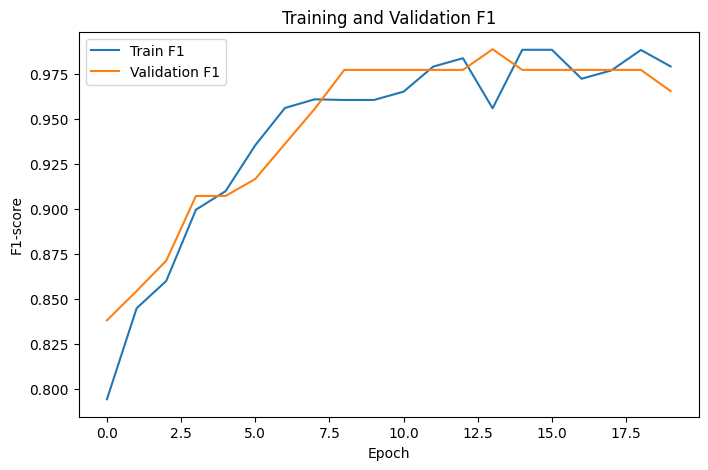

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_auc"], label="Train AUC")
plt.plot(history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training and Validation AUC")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_f1"], label="Train F1")
plt.plot(history["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training and Validation F1")
plt.legend()
plt.show()


# Test Evaluation
##  Setup and Configuration

In [1]:
from pathlib import Path
CHECKPOINT_PATH = Path(r"../models/augmented_glaucoma_efficientnet_b0.pth")

MODEL_NAME_OVERRIDE = None
TEST_SPLIT_CSV = None
IMAGE_DIR = None
BATCH_SIZE = None


In [3]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


## Dataset Class and Transforms

In [4]:
class GlaucomaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = str(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["Image Name"])
        image = Image.open(img_path).convert("RGB")
        label = int(row["Label_Binary"])

        if self.transform:
            image = self.transform(image)

        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Load Checkpoint and Extract Metadata

In [5]:

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

checkpoint_model_name = checkpoint.get("model_name", None)
if checkpoint_model_name is None:
    raise ValueError(
        "Checkpoint does not contain 'model_name'. "
        "Re-save the training checkpoint with model_name included."
    )

model_name = MODEL_NAME_OVERRIDE if MODEL_NAME_OVERRIDE is not None else checkpoint_model_name
model_name = model_name.lower()

best_thresh = float(checkpoint.get("best_threshold", 0.5))

checkpoint_test_csv = checkpoint.get("test_split_csv", None)
checkpoint_image_dir = checkpoint.get("image_dir", None)
checkpoint_batch_size = checkpoint.get("batch_size", 16)

TEST_SPLIT_CSV = Path(TEST_SPLIT_CSV) if TEST_SPLIT_CSV is not None else Path(checkpoint_test_csv)
IMAGE_DIR = Path(IMAGE_DIR) if IMAGE_DIR is not None else Path(checkpoint_image_dir)
BATCH_SIZE = int(BATCH_SIZE) if BATCH_SIZE is not None else int(checkpoint_batch_size)

print("Loaded checkpoint   :", CHECKPOINT_PATH)
print("Checkpoint model    :", checkpoint_model_name)
print("Test model          :", model_name)
print("Best threshold      :", round(best_thresh, 4))
print("Best stage          :", checkpoint.get("best_stage"))
print("Best val AUC        :", round(float(checkpoint.get("best_val_auc", 0.0)), 4))
print("Test split CSV      :", TEST_SPLIT_CSV)
print("Image dir           :", IMAGE_DIR)
print("Batch size          :", BATCH_SIZE)


Loaded checkpoint   : ..\models\augmented_glaucoma_efficientnet_b0.pth
Checkpoint model    : efficientnet_b0
Test model          : efficientnet_b0
Best threshold      : 0.4
Best stage          : Stage 2 (last blocks + classifier)
Best val AUC        : 0.992
Test split CSV      : ..\data\processed\test_split.csv
Image dir           : ..\data\processed\preprocessed_glaucoma
Batch size          : 16


## Build Model and Load Weights

In [6]:
def build_model(model_name: str):
    model_name = model_name.lower()

    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
        return model

    elif model_name == "resnet50":
        model = models.resnet50(weights=None)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 1)
        )
        return model

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 1)
        )
        return model

    else:
        raise ValueError(
            f"Unsupported model_name: {model_name}. "
            "Supported: resnet18, resnet50, efficientnet_b0."
        )

model = build_model(model_name)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")


Model loaded successfully.


## Load Test Data

In [7]:
test_df = pd.read_csv(TEST_SPLIT_CSV)
test_df = test_df[["Image Name", "Label_Binary"]].dropna().copy()
test_df["Patient_ID"] = test_df["Image Name"].astype(str).apply(lambda x: x.split("_")[0])

print("Test images   :", len(test_df))
print("Test patients :", test_df["Patient_ID"].nunique())
print("Label distribution:")
print(test_df["Label_Binary"].value_counts())

test_dataset = GlaucomaDataset(test_df, IMAGE_DIR, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Test batches:", len(test_loader))

Test images   : 73
Test patients : 32
Label distribution:
Label_Binary
1    47
0    26
Name: count, dtype: int64
Test batches: 5


## Evaluation 

In [8]:
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()

        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())

y_true = np.array(all_labels)
y_prob = np.array(all_probs)
y_pred = (y_prob >= best_thresh).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0

print("\n================ TEST RESULTS ================")
print(f"Model         : {model_name}")
print(f"Threshold     : {best_thresh:.4f}")
print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")
print(f"Test ROC-AUC  : {auc:.4f}")
print(f"Sensitivity   : {sensitivity:.4f}")
print(f"Specificity   : {specificity:.4f}")
print("\nConfusion Matrix:")
print(cm)


================ TEST RESULTS ================
Model         : efficientnet_b0
Threshold     : 0.4000
Test Accuracy : 0.9452
Test Precision: 0.9216
Test Recall   : 1.0000
Test F1-score : 0.9592
Test ROC-AUC  : 0.9885
Sensitivity   : 1.0000
Specificity   : 0.8462

Confusion Matrix:
[[22  4]
 [ 0 47]]


## Visualization 1 : The Zero‑Miss Matrix (Confusion Matrix)
#### use the confusion matrix from Best Model test results to emphasize the 100% Recall (0 False Negatives) achievement.

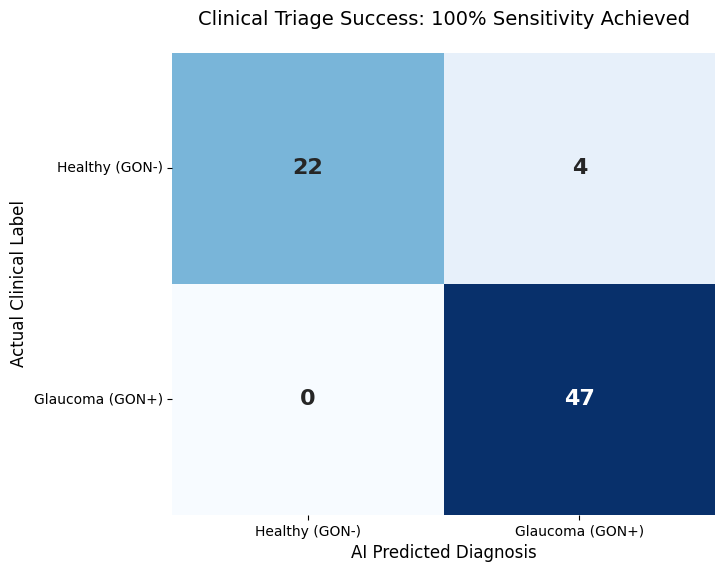

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16, "weight": "bold"})

plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('Actual Clinical Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Healthy (GON-)', 'Glaucoma (GON+)'])
plt.yticks([0.5, 1.5], ['Healthy (GON-)', 'Glaucoma (GON+)'], rotation=0)
plt.title('Clinical Triage Success: 100% Sensitivity Achieved', fontsize=14, pad=20)
plt.show()

## Visualization 2 : Prediction Confidence Distribution (Reliability Plot)
- shows how "sure" the model is when it predicts Glaucoma vs. Healthy eyes.

The histogram shows the distribution of predicted probabilities, split by actual class.
A bimodal separation (peaks near 0 for healthy eyes and near 1 for glaucoma eyes) indicates that the model is highly confident in its predictions.
The vertical dashed line marks the tuned threshold (0.62). The clear gap between the two classes demonstrates that the model reliably distinguishes glaucoma from healthy cases, minimising ambiguity.

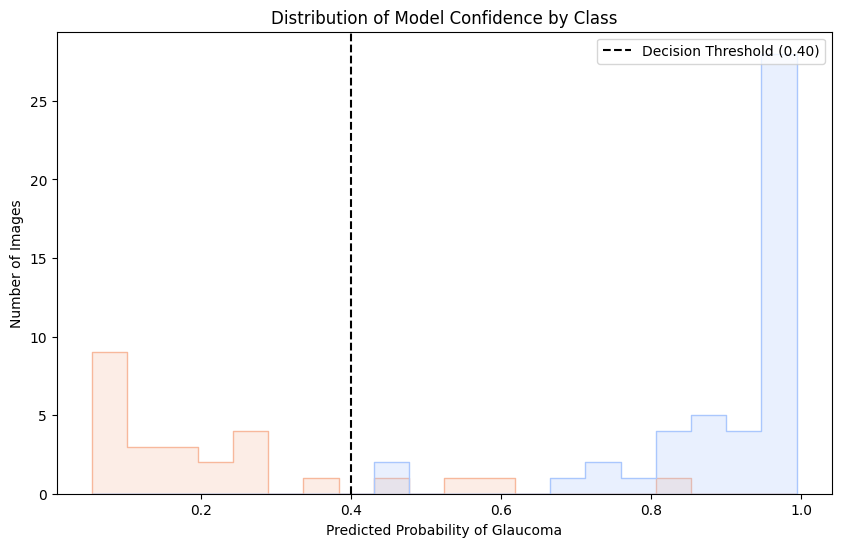

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# all_probs and all_labels come from your Test Results block
plt.figure(figsize=(10, 6))
df_probs = pd.DataFrame({'Probability': all_probs, 'Actual Label': all_labels})
df_probs['Actual Label'] = df_probs['Actual Label'].map({0: 'Healthy (GON-)', 1: 'Glaucoma (GON+)'})

sns.histplot(data=df_probs, x='Probability', hue='Actual Label', element='step', common_norm=False, palette='coolwarm', bins=20)
plt.axvline(x=best_thresh, color='black', linestyle='--', label=f'Decision Threshold ({best_thresh:.2f})')
plt.title('Distribution of Model Confidence by Class')
plt.xlabel('Predicted Probability of Glaucoma')
plt.ylabel('Number of Images')
plt.legend()
plt.show()

The dashed line marks the decision threshold (tuned on validation). The wide valley between the two peaks means there is little ambiguity which means the model rarely produces uncertain predictions. This confirms the model’s reliability and low risk of misclassification in real‑world use.

## Visualization 3 : ROC Curve

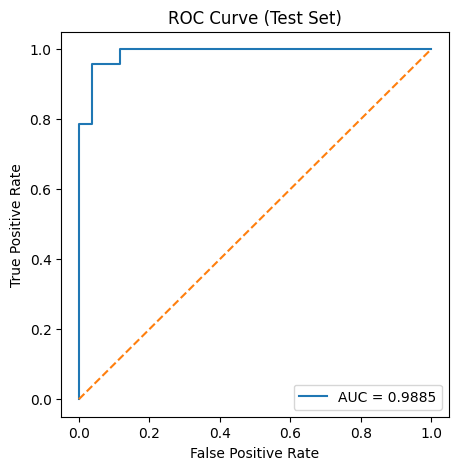

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()

plt.show()

## Risk Grouping and Saving Predictions
We assign each test image to a risk category based on its raw probability:

* Low Risk (p < 0.30)

* Moderate Risk (0.30 ≤ p < 0.70)

* High Risk (p ≥ 0.70)

Both the risk groupings and the full predictions (with probabilities and predicted labels) are saved to CSV files for further analysis.

In [12]:
def risk_category(p):
    if p < 0.30:
        return "Low Risk"
    elif p < 0.70:
        return "Moderate Risk"
    return "High Risk"

risk_df_test = pd.DataFrame({
    "true_label": y_true,
    "probability": y_prob,
    "pred_label": y_pred,
})
risk_df_test["risk_group"] = risk_df_test["probability"].apply(risk_category)

print("\nTest risk group counts:")
print(risk_df_test["risk_group"].value_counts())

risk_out_path = Path(TEST_SPLIT_CSV).with_name(f"test_risk_groups_{model_name}.csv")
risk_df_test.to_csv(risk_out_path, index=False)
print("Saved test risk groups to:", risk_out_path)

risk_df_test.head()



Test risk group counts:
risk_group
High Risk        45
Low Risk         21
Moderate Risk     7
Name: count, dtype: int64
Saved test risk groups to: ..\data\processed\test_risk_groups_efficientnet_b0.csv


,true_label,probability,pred_label,risk_group
0,1,0.971711,1,High Risk
1,1,0.739494,1,High Risk
2,1,0.912116,1,High Risk
3,1,0.950557,1,High Risk
4,1,0.976573,1,High Risk


In [13]:
# SAVE PREDICTIONS (OPTIONAL)
pred_df = test_df.copy()
pred_df["prob_glaucoma"] = y_prob
pred_df["pred_label"] = y_pred
pred_df["risk_group"] = pred_df["prob_glaucoma"].apply(risk_category)

out_path = Path(TEST_SPLIT_CSV).with_name(f"test_predictions_{model_name}.csv")
pred_df.to_csv(out_path, index=False)
print("Saved predictions to:", out_path)
pred_df.head()

Saved predictions to: ..\data\processed\test_predictions_efficientnet_b0.csv


,Image Name,Label_Binary,Patient_ID,prob_glaucoma,pred_label,risk_group
0,0_0.jpg,1,0,0.971711,1,High Risk
1,41_0.jpg,1,41,0.739494,1,High Risk
2,47_0.jpg,1,47,0.912116,1,High Risk
3,47_1.jpg,1,47,0.950557,1,High Risk
4,47_3.jpg,1,47,0.976573,1,High Risk
